# Preprocessing - Wine Quality Dataset

This program:

1. Loads the original wine quality dataset.
2. Checks null values, duplicates, and class distribution.
3. Calculates Pearson correlation.
4. Reorders attributes using Pearson correlation.
5. Runs PCA analysis as exploratory analysis.
6. Runs Shapiro-Wilk test as exploratory analysis.
7. Splits train/test.
8. Applies `StandardScaler` using only the training set.
9. Saves:
   - `preprocessed_train.csv`
   - `preprocessed_test.csv`

## Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

## 1. Load Dataset

In [11]:
# Wine Quality datasets use ; as separator.
df = pd.read_csv("../Dataset/winequality-white.csv", sep=";")

print("Dataset shape:", df.shape)
df.head()


Dataset shape: (4898, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


## 2. Data cleaning & data verification

In [13]:
# null values?
if df.isnull().values.any():
    print("There are null values in the dataset, data cleaning is required.")
else:
    print("There are no null values in the dataset, data is clean.")

# duplicated values?
if df.duplicated().values.any():
    print("There are duplicated rows in the dataset, and are {} in total.".format(df.duplicated().sum()))
else:
    print("There are no duplicated rows in the dataset.")

# how is distribution between classes?
print("\nQuality distribution:")
print(df["quality"].value_counts().sort_index())


There are no null values in the dataset, data is clean.
There are duplicated rows in the dataset, and are 937 in total.

Quality distribution:
quality
3      20
4     163
5    1457
6    2198
7     880
8     175
9       5
Name: count, dtype: int64


## 3. Separate attributes and labels

In [21]:
# Attributes
X = df.drop("quality", axis=1)

# Label
y = df["quality"]

print(y.head(5))
X.head()

0    6
1    6
2    6
3    6
4    6
Name: quality, dtype: int64


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9


## 4. Pearson correlation analysis

The paper [incluir cita] uses Pearson correlation to analyze the relation between wine properties.

This will be used by 1D-CNN model to reorder attributes and understand better the relationships between them.


Correlation by quality:
alcohol                 0.435575
density                -0.307123
chlorides              -0.209934
volatile acidity       -0.194723
total sulfur dioxide   -0.174737
fixed acidity          -0.113663
pH                      0.099427
residual sugar         -0.097577
sulphates               0.053678
citric acid            -0.009209
free sulfur dioxide     0.008158
Name: quality, dtype: float64


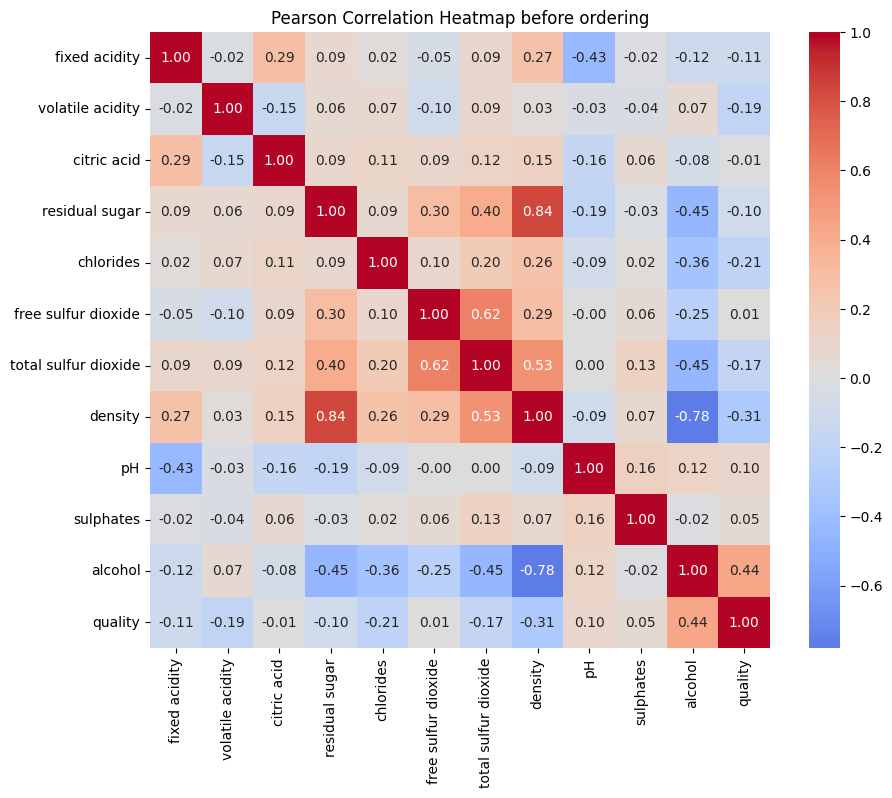

In [22]:
corr_matrix = df.corr(method="pearson")

quality_corr = corr_matrix["quality"].drop("quality")
quality_corr = quality_corr.reindex(
    quality_corr.abs().sort_values(ascending=False).index
)

print("Correlation by quality:")
print(quality_corr)

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Pearson Correlation Heatmap before ordering")
plt.show()


## 5. Reorder atrributes based on Pearson correlation

1. Start with the most correlated attribute with **quality**.
2. Add the remaining attributes with descendant correlation value.


In [23]:
def build_pearson_attributes_order(corr_matrix, target="quality"):
    attribute_corr = corr_matrix.drop(index=target, columns=target)
    quality_corr_abs = corr_matrix[target].drop(target).abs()
    
    first_attribute = quality_corr_abs.idxmax()

    attribute_order = [first_attribute]
    remaining_attributes = set(attribute_corr.columns) - {first_attribute}

    while remaining_attributes:
        last_attribute = attribute_order[-1]

        next_attribute = (
            attribute_corr.loc[last_attribute, list(remaining_attributes)]
            .abs()
            .sort_values(ascending=False)
            .index[0]
        )

        attribute_order.append(next_attribute)
        remaining_attributes.remove(next_attribute)

    return attribute_order

attribute_order = build_pearson_attributes_order(corr_matrix)

print("Attribute order by Pearson correlation:")
for i, attribute in enumerate(attribute_order, start=1):
    print(f"{i}. {attribute}")


Attribute order by Pearson correlation:
1. alcohol
2. density
3. residual sugar
4. total sulfur dioxide
5. free sulfur dioxide
6. chlorides
7. citric acid
8. fixed acidity
9. pH
10. sulphates
11. volatile acidity


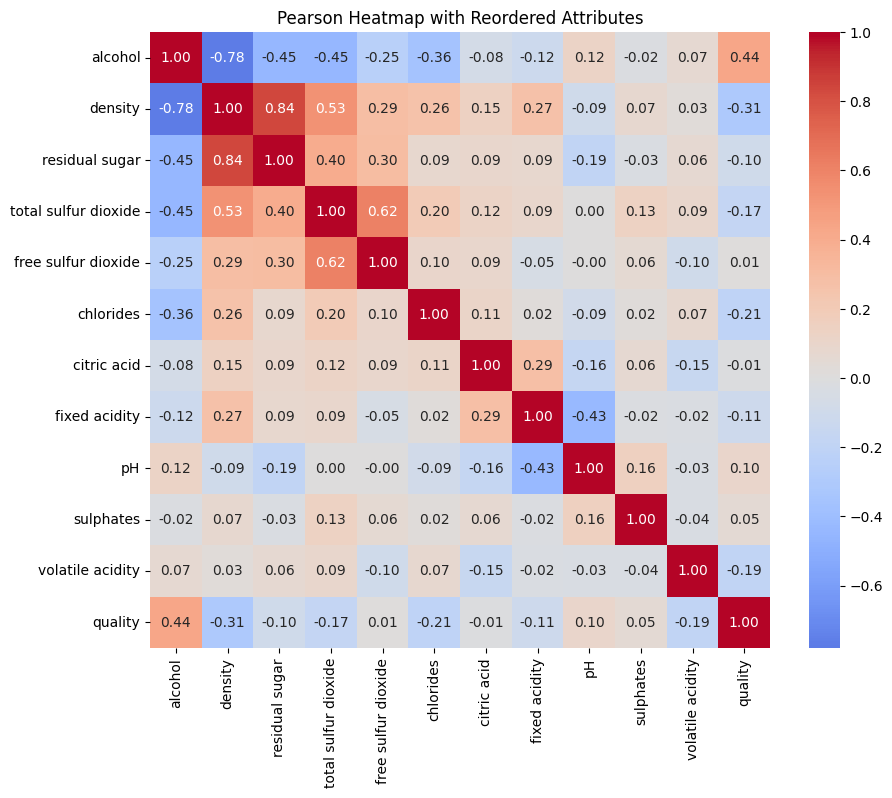

In [24]:
ordered_corr_matrix = df[attribute_order + ["quality"]].corr(method="pearson")

plt.figure(figsize=(10, 8))
sns.heatmap(
    ordered_corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Pearson Heatmap with Reordered Attributes")
plt.show()

# It might be similar to a Minecraft axe


## 6. Split the dataset

In [25]:
# Reorder the attributes before the split.
X_ordered = X[attribute_order]

X_train, X_test, y_train, y_test = train_test_split(
    X_ordered,
    y,
    test_size=.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nTrain quality distribution:")
print(y_train.value_counts().sort_index())

print("\nTest quality distribution:")
print(y_test.value_counts().sort_index())


Train shape: (3918, 11)
Test shape: (980, 11)

Train quality distribution:
quality
3      16
4     130
5    1166
6    1758
7     704
8     140
9       4
Name: count, dtype: int64

Test quality distribution:
quality
3      4
4     33
5    291
6    440
7    176
8     35
9      1
Name: count, dtype: int64


## 7. Scaling - (Z-score normalization)

The paper [incluir cita] also includes PCA as an option in preprocessing to scale data.

Why?
Besides from dataleakage, we don't want the model to ignore data because of different scales.

The following formula is implamented:

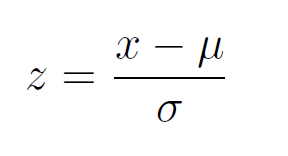

Where 
- x = original value of an attribute.
- μ (mu) = mean of that attribute.
- σ (sigma) = standard deviation of that attribute.
- z = scaled value.

In [26]:
scaler = StandardScaler() # This function works as the formula explained previously

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled_df = pd.DataFrame(
    X_train_scaled,
    columns=attribute_order,
    index=X_train.index
)

X_test_scaled_df = pd.DataFrame(
    X_test_scaled,
    columns=attribute_order,
    index=X_test.index
)


## 8. Save preprocessed datasets

In [27]:
# rebuild datasets with labels
train_df = pd.concat([X_train_scaled_df, y_train], axis=1) # axis = 1: organize categories by columns
test_df = pd.concat([X_test_scaled_df, y_test], axis=1) # axis = 1: organize categories by columns

# Save datasets in corresponding folders
train_df.to_csv("../Dataset/train/preprocessed_train.csv", index=False)
test_df.to_csv("../Dataset/test/preprocessed_test.csv", index=False)